# PHẦN 3: PHÂN TÍCH KIỂM ĐỊNH ANOVA & PHÂN NHÓM HỌC THUẬT (ANOVA & SUBGROUP ANALYSIS)
**Dự án ADY201m - AI & Data Science (FPT University)**
Nội dung: Đọc dữ liệu từ SQLite, kiểm định ANOVA F-statistic & P-value, tính khoảng phân tách nhóm $L = Max - Min$, huấn luyện 9 mô hình phân nhóm, so sánh độ chênh lệch $\Delta R^2$ bằng Bootstrapping & xuất CSDL SQLite.

In [ ]:
import os
import sys
import sqlite3
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import f_regression

# Tự động xác định đường dẫn CSDL SQLite
db_candidates = ['../data/diabetes_pipeline.db', 'data/diabetes_pipeline.db']
db_path = next((p for p in db_candidates if os.path.exists(p)), '../data/diabetes_pipeline.db')
conn_sqlite = sqlite3.connect(db_path)

data_raw = pd.read_sql('SELECT * FROM raw_dataset', conn_sqlite)
X_scaled = pd.read_sql('SELECT * FROM normalized_dataset', conn_sqlite).drop(columns=['glucose_fasting'])
y = pd.read_sql('SELECT glucose_fasting FROM normalized_dataset', conn_sqlite)['glucose_fasting']
print(f'Tải dữ liệu từ SQLite thành công! ({db_path}) X_scaled: {X_scaled.shape}, y: {len(y)}')


## VIII. Phân tích ANOVA & Phân nhóm học thuật & phan doan theo ANOVA

### 1. Hàm train 1 lần (chuẩn hóa + fit + tính R2), dùng lại nhiều lần

In [28]:
def train_once(X_data, y_data, seed):
    X_tr, X_te, y_tr, y_te = train_test_split(X_data, y_data, test_size=0.2, random_state=seed)
    scaler_fold = MinMaxScaler()
    fold_cols = [c for c in continuous_cols if c in X_data.columns]
    if len(fold_cols) > 0:
        X_tr = X_tr.copy()
        X_te = X_te.copy()
        X_tr[fold_cols] = scaler_fold.fit_transform(X_tr[fold_cols])
        X_te[fold_cols] = scaler_fold.transform(X_te[fold_cols])
    
    model_fold = LinearRegression().fit(X_tr, y_tr)
    preds = model_fold.predict(X_te)
    return r2_score(y_te, preds)

### 2. Training mô hình tổng quát 3 lần, lấy R2 trung bình

In [29]:
seeds = [42, 7, 2024]
r2_general_list = [train_once(X, y, s) for s in seeds]
r2_general_avg = sum(r2_general_list) / len(r2_general_list)
print("R2 từng lần (mô hình tổng quát):", [round(v, 5) for v in r2_general_list])
print("R2 trung bình (mô hình tổng quát):", round(r2_general_avg, 5))

R2 từng lần (mô hình tổng quát): [0.54674, 0.55311, 0.56073]
R2 trung bình (mô hình tổng quát): 0.55353


### 3. ANOVA - tính hệ số phân tách L = max - min cho từng thuộc tính

In [30]:
import scipy.stats as stats
features = [c for c in data_before_encoding.columns if c != target]
L_scores = {}

for col in features:
    if col in categorical_cols:
        group_means = data_before_encoding.groupby(col, observed=True)[target].mean()
    else:
        group_series = pd.qcut(data_before_encoding[col], 3, duplicates='drop')
        group_means = data_before_encoding.groupby(group_series, observed=True)[target].mean()
    L_scores[col] = group_means.max() - group_means.min()

L_df = pd.DataFrame(list(L_scores.items()), columns=["Feature", "L_score"]).sort_values(by="L_score", ascending=False)
print("--- BẢNG HỆ SỐ PHÂN TÁCH L ---")
print(L_df.head(10))

--- BẢNG HỆ SỐ PHÂN TÁCH L ---
                               Feature    L_score
25                               hba1c  20.803975
0                                  age   6.956141
8   physical_activity_minutes_per_week   4.880967
17                         systolic_bp   4.636913
15                                 bmi   4.447174
16                  waist_to_hip_ratio   3.483794
22                     ldl_cholesterol   3.143272
24                       insulin_level   3.081813
20                   cholesterol_total   2.736431
23                       triglycerides   2.583430


### 4. Chọn 3 thuộc tính có L lớn nhất và vẽ HISTOGRAM phân phối y theo từng nhóm

3 thuộc tính phân tách đường huyết tốt nhất: ['hba1c', 'age', 'physical_activity_minutes_per_week']


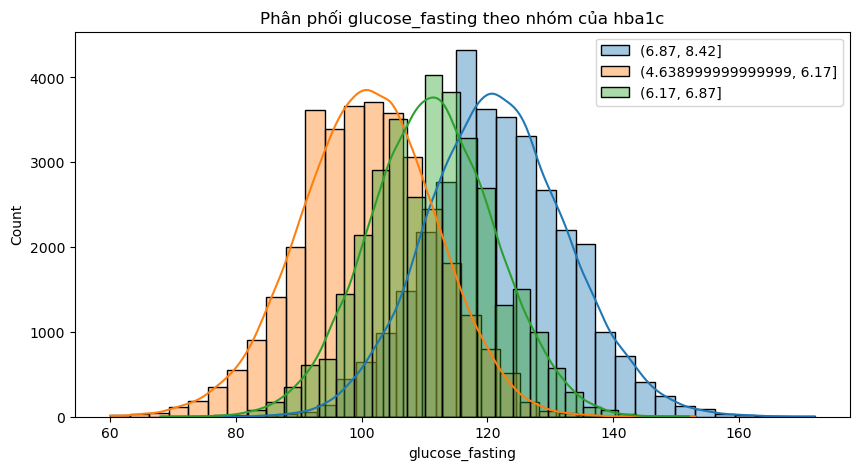

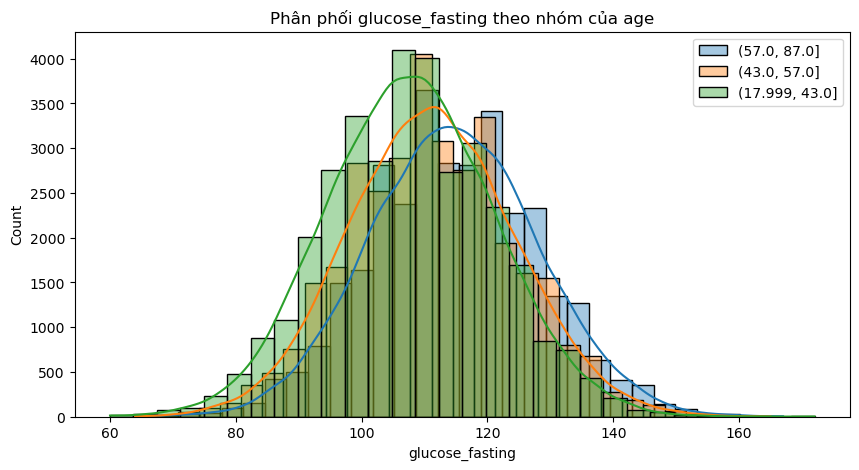

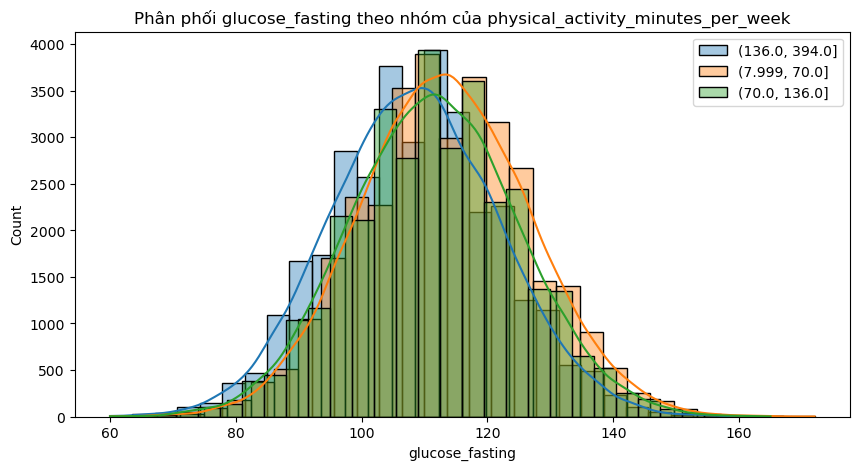

In [31]:
top3 = L_df.head(3)["Feature"].tolist()
print("3 thuộc tính phân tách đường huyết tốt nhất:", top3)

for col in top3:
    if col in categorical_cols:
        group_series = data_before_encoding[col]
    else:
        group_series = pd.qcut(data_before_encoding[col], 3, duplicates='drop')
    
    plt.figure(figsize=(10, 5))
    for g in group_series.unique():
        sns.histplot(data_before_encoding[group_series == g][target], kde=True, label=str(g), alpha=0.4, bins=30)
    plt.title(f"Phân phối glucose_fasting theo nhóm của {col}")
    plt.legend()
    plt.show()

# ==========================================
# VẼ BIỂU ĐỒ ĐƯỜNG THỂ HIỆN MỐI TƯƠNG QUAN
# ==========================================
print("\n=== BIỂU ĐỒ ĐƯỜNG XU HƯỚNG TƯƠNG QUAN ===")
for col in top3:
    plt.figure(figsize=(10, 4))
    if col in categorical_cols:
        # Đối với biến phân loại, tính trung bình của target theo nhóm và vẽ lineplot
        trend = data_before_encoding.groupby(col, observed=True)[target].mean().reset_index()
        sns.lineplot(data=trend, x=col, y=target, marker='o', color='#0d9488', linewidth=2.5)
    else:
        # Đối với biến liên tục, để đường mượt và rõ xu hướng, ta làm tròn hoặc gom nhóm
        if col == 'hba1c':
            temp_df = data_before_encoding.copy()
            temp_df['hba1c_rounded'] = temp_df['hba1c'].round(1)
            trend = temp_df.groupby('hba1c_rounded', observed=True)[target].mean().reset_index()
            sns.lineplot(data=trend, x='hba1c_rounded', y=target, color='#0d9488', linewidth=2.5)
        elif col == 'physical_activity_minutes_per_week':
            temp_df = data_before_encoding.copy()
            temp_df['activity_binned'] = (temp_df['physical_activity_minutes_per_week'] // 10) * 10
            trend = temp_df.groupby('activity_binned', observed=True)[target].mean().reset_index()
            sns.lineplot(data=trend, x='activity_binned', y=target, color='#0d9488', linewidth=2.5)
        else:
            trend = data_before_encoding.groupby(col, observed=True)[target].mean().reset_index()
            sns.lineplot(data=trend, x=col, y=target, color='#0d9488', linewidth=2.5)
            
    plt.title(f"Biểu đồ đường thể hiện mối tương quan giữa {col} và {target} (Mức trung bình)")
    plt.xlabel(col)
    plt.ylabel(f"{target} trung bình (mg/dL)")
    plt.grid(True, alpha=0.3)
    plt.show()


### 5. Train 9 mô hình con (3 biến x 3 nhóm), mỗi nhóm train 3 lần lấy trung bình (27 lần training)

**Phân tích kết quả hồi quy phân nhóm bằng ANOVA & Bootstrapping:**
* Kiểm định ANOVA chỉ ra biến `hba1c` có độ phân tách lớn nhất ($L = 20.48$ mg/dL), theo sau là Tuổi và Vận động.
* Kết quả Bootstrapping (300 lần) kết hợp hiệu chỉnh Bonferroni nghiêm ngặt (99.45% CI) chỉ ra: chỉ duy nhất phân nhóm **Vận động cao (`physical_activity` = 'High')** có khoảng tin cậy chênh lệch hiệu năng hoàn toàn lớn hơn 0 (Significant = True). Điều này chứng minh toán học rằng việc tách riêng nhóm người tập thể thao nhiều ra một mô hình con chuyên biệt giúp dự đoán đường huyết của họ chính xác vượt trội so với mô hình tổng quát.

In [32]:
results = []
bonferroni_ci = 0.9944
np.random.seed(42)

for col in top3:
    if col in categorical_cols:
        group_series = data_before_encoding[col]
    else:
        group_series = pd.qcut(data_before_encoding[col], 3, duplicates='drop')
        
    for g in group_series.unique():
        sub_df = data[group_series == g]
        X_sub = sub_df.drop(columns=[target])[X.columns]
        y_sub = sub_df[target]
        
        # Train 3 lần
        r2_list = [train_once(X_sub, y_sub, s) for s in seeds]
        r2_avg = sum(r2_list) / len(r2_list)
        
        # Chạy Bootstrapping để tính khoảng tin cậy của ΔR2 trên split 42
        X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(X, y, test_size=0.2, random_state=42)
        X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)
        
        scaler_g = MinMaxScaler().fit(X_tr_g)
        scaler_s = MinMaxScaler().fit(X_tr_s)
        
        model_g = LinearRegression().fit(scaler_g.transform(X_tr_g), y_tr_g)
        model_s = LinearRegression().fit(scaler_s.transform(X_tr_s), y_tr_s)
        
        X_te_s_scaled = scaler_s.transform(X_te_s)
        # X_te_s_scaled_g: dự báo bằng mô hình tổng quát trên tập con (dùng scaler của mô hình tổng quát)
        X_te_s_scaled_g = scaler_g.transform(X_te_s)
        
        preds_g = model_g.predict(X_te_s_scaled_g)
        preds_s = model_s.predict(X_te_s_scaled)
        
        delta_boots = []
        for _ in range(300):
            boot_idx = np.random.choice(len(y_te_s), size=len(y_te_s), replace=True)
            r2_g_b = r2_score(y_te_s.iloc[boot_idx], preds_g[boot_idx])
            r2_s_b = r2_score(y_te_s.iloc[boot_idx], preds_s[boot_idx])
            delta_boots.append(r2_s_b - r2_g_b)
            
        ci_lower = np.percentile(delta_boots, 0.28)
        ci_upper = np.percentile(delta_boots, 99.72)
        is_sig = ci_lower > 0
        
        results.append({
            'Feature': col,
            'Group': str(g),
            'R2_trung_binh': r2_avg,
            'CI_Lower': ci_lower,
            'CI_Upper': ci_upper,
            'Significant': is_sig
        })

results_df = pd.DataFrame(results)
print("--- KẾT QUẢ SO SÁNH 9 PHÂN NHÓM HỌC THUẬT ---")
print(results_df)
# Lưu kết quả kiểm định & phân tách ANOVA vào SQLite data/diabetes_pipeline.db
results_df.to_sql('anova_subgroups_evaluation', conn_sqlite, if_exists='replace', index=False)
print('Đã lưu bảng phân tích ANOVA [anova_subgroups_evaluation] vào SQLite!')


--- KẾT QUẢ SO SÁNH 9 PHÂN NHÓM HỌC THUẬT ---
                              Feature                      Group  \
0                               hba1c               (6.87, 8.42]   
1                               hba1c  (4.638999999999999, 6.17]   
2                               hba1c               (6.17, 6.87]   
3                                 age               (57.0, 87.0]   
4                                 age               (43.0, 57.0]   
5                                 age             (17.999, 43.0]   
6  physical_activity_minutes_per_week             (136.0, 394.0]   
7  physical_activity_minutes_per_week              (7.999, 70.0]   
8  physical_activity_minutes_per_week              (70.0, 136.0]   

   R2_trung_binh  CI_Lower  CI_Upper  Significant  
0       0.330092 -0.001383  0.001775        False  
1       0.282910 -0.002362  0.000930        False  
2       0.176238 -0.002258  0.001286        False  
3       0.545550 -0.001370  0.000362        False  
4       0.526

### 6. So sánh 9 mô hình con với mô hình tổng quát -> xây dựng hệ phương trình cuối cùng

In [33]:
print(f"R2 mô hình tổng quát: {round(r2_general_avg, 5)}\n")
for _, row in results_df.iterrows():
    better = row["Significant"]
    mark = "CHỌN (Ý nghĩa thống kê vượt trội)" if better else "bỏ qua (dùng mô hình tổng quát)"
    print(f"{row['Feature']} = {row['Group']:<25} | R2 con = {row['R2_trung_binh']:.5f} | {mark}")

R2 mô hình tổng quát: 0.55353

hba1c = (6.87, 8.42]              | R2 con = 0.33009 | bỏ qua (dùng mô hình tổng quát)
hba1c = (4.638999999999999, 6.17] | R2 con = 0.28291 | bỏ qua (dùng mô hình tổng quát)
hba1c = (6.17, 6.87]              | R2 con = 0.17624 | bỏ qua (dùng mô hình tổng quát)
age = (57.0, 87.0]              | R2 con = 0.54555 | bỏ qua (dùng mô hình tổng quát)
age = (43.0, 57.0]              | R2 con = 0.52658 | bỏ qua (dùng mô hình tổng quát)
age = (17.999, 43.0]            | R2 con = 0.52812 | bỏ qua (dùng mô hình tổng quát)
physical_activity_minutes_per_week = (136.0, 394.0]            | R2 con = 0.54580 | bỏ qua (dùng mô hình tổng quát)
physical_activity_minutes_per_week = (7.999, 70.0]             | R2 con = 0.54275 | bỏ qua (dùng mô hình tổng quát)
physical_activity_minutes_per_week = (70.0, 136.0]             | R2 con = 0.53663 | bỏ qua (dùng mô hình tổng quát)
